# How K-Means Clustering Finds Patterns in Unlabelled Data

**Author:** Suthagar Thanushayan  
**Course:** 7PAM2002 – Machine Learning and Neural Networks  
**University of Hertfordshire**  
**GitHub:**https://github.com/thanushayan/kmeans_clustering_tutorial.git

---

## Overview

machine learning problems assume we have labelled data — we know the answer before we train. But what if we have no labels at all? **Unsupervised learning** lets us discover hidden structure in data without any guidance.

In this tutorial we focus on **K-Means Clustering** — one of the most widely used and intuitive unsupervised algorithms. We will:

1. Understand **how K-Means works** step by step (the algorithm)
2. Visualise the algorithm **converging** in real time
3. Learn how to **choose K** using the Elbow Method and Silhouette Score
4. Apply K-Means to a **real dataset** (Mall Customer Segmentation)
5. Understand the **limitations** of K-Means

**Libraries used:** `numpy`, `matplotlib`, `seaborn`, `scikit-learn` — no TensorFlow required.

**Dataset:** Mall Customer Segmentation dataset (Kaggle) — Annual Income vs Spending Score

---



## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

import pandas as pd

# Colour-blind friendly palette (Wong, 2011)
CB_COLORS = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_COLORS)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded successfully. No TensorFlow required!")
import sklearn; print(f"scikit-learn version: {sklearn.__version__}")

All libraries loaded successfully. No TensorFlow required!
scikit-learn version: 1.6.1


## Step 2: What is K-Means? The Algorithm Explained

K-Means partitions a dataset of **n** points into **K** clusters. Each point belongs to the cluster with the nearest centroid (mean). The algorithm minimises the **Within-Cluster Sum of Squares (WCSS)**:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

where $\mu_k$ is the mean (centroid) of cluster $C_k$.

### The Algorithm (Lloyd's Algorithm, 1957)

```
1. Choose K — the number of clusters
2. Initialise K centroids randomly
3. REPEAT until convergence:
   a. ASSIGNMENT: assign each point to the nearest centroid
   b. UPDATE: move each centroid to the mean of its assigned points
4. STOP when centroids no longer move significantly
```

This is guaranteed to converge, but may find a **local minimum** — hence the importance of multiple restarts (`n_init` in scikit-learn).

## Step 3: Visualise the K-Means Algorithm Step by Step

Let us generate a simple dataset and watch K-Means converge iteration by iteration.

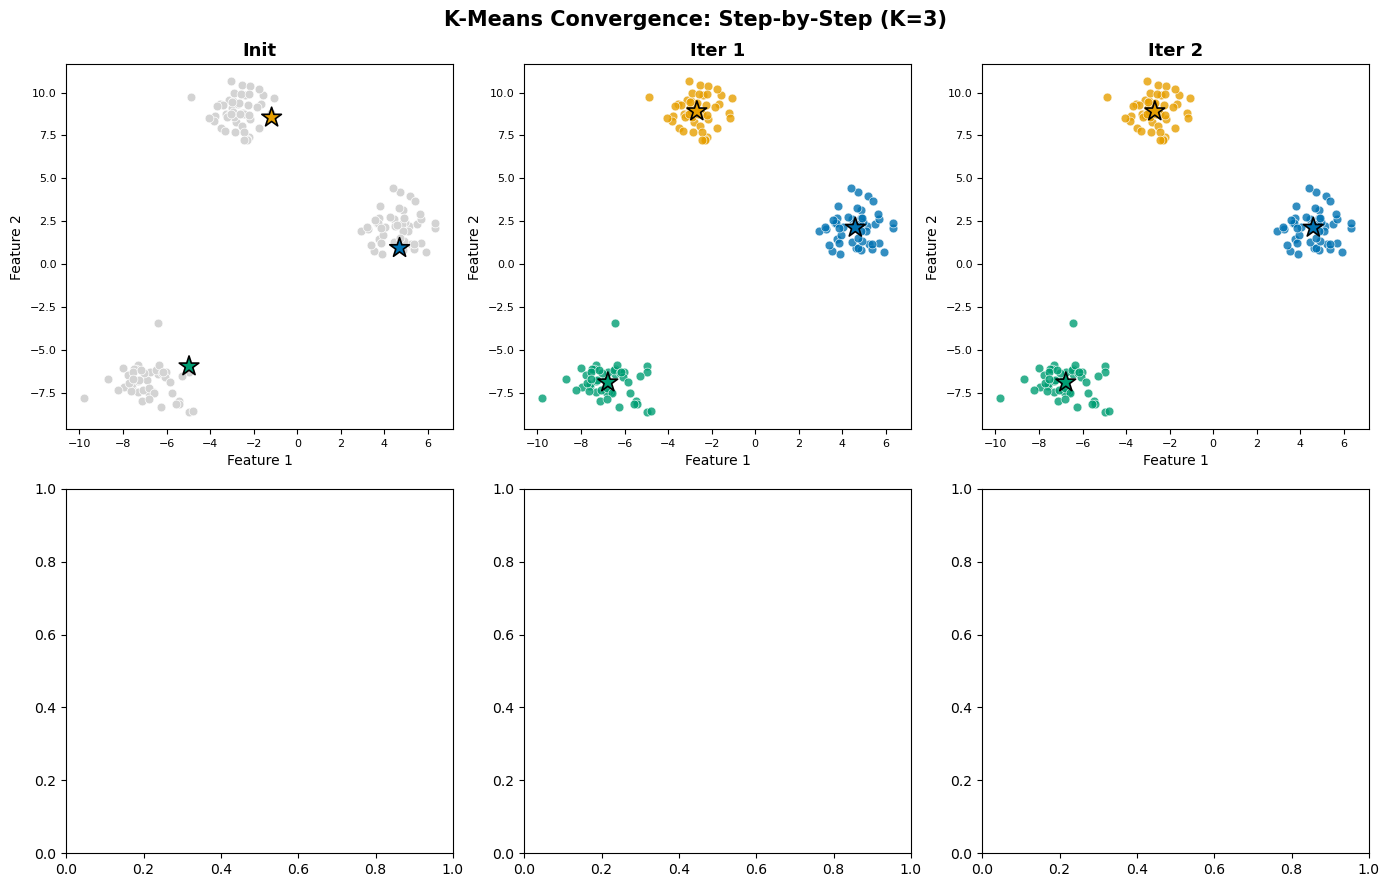

Figure 1 saved.


In [2]:
# Generate synthetic dataset with 3 clear clusters
np.random.seed(42)
X, y_true = make_blobs(n_samples=150, centers=3, cluster_std=0.9, random_state=42)

# Manually implement one run of K-Means to visualise steps
def kmeans_steps(X, k=3, n_iter=5, seed=10):
    np.random.seed(seed)
    # Random initialisation
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx].copy()
    history = [('Init', centroids.copy(), np.zeros(len(X), dtype=int))]

    for i in range(n_iter):
        # Assignment step
        dists = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(dists, axis=1)
        # Update step
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        history.append((f'Iter {i+1}', new_centroids.copy(), labels.copy()))
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return history

history = kmeans_steps(X, k=3, n_iter=6)

# Plot first 6 states
n_plots = min(6, len(history))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

markers = ['o', 's', '^']
for ax, (title, centroids, labels) in zip(axes, history):
    if title == 'Init':
        ax.scatter(X[:, 0], X[:, 1], c='lightgrey', s=40, edgecolors='white', linewidth=0.5, label='Unassigned')
    else:
        for k in range(3):
            mask = labels == k
            ax.scatter(X[mask, 0], X[mask, 1], c=CB_COLORS[k], s=40,
                       edgecolors='white', linewidth=0.5, alpha=0.8)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c=CB_COLORS[:3], s=220, marker='*', edgecolors='black', linewidth=1.2,
               zorder=5, label='Centroids')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=10)
    ax.set_ylabel('Feature 2', fontsize=10)
    ax.tick_params(labelsize=8)

fig.suptitle('K-Means Convergence: Step-by-Step (K=3)', fontsize=15, fontweight='bold')
# Alt text: 6-panel plot showing K-Means over iterations. Panel 1 shows random centroids (stars) 
# with unassigned grey points. Subsequent panels show points assigned to clusters (blue/orange/green)
# and centroids moving toward cluster centres until convergence.
plt.tight_layout()
plt.savefig('fig1_kmeans_steps.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved.")

## Step 4: The Elbow Method — Choosing the Right K

K-Means requires you to specify K in advance. A common technique is to plot the **WCSS (inertia)** for different values of K and look for the "elbow" — the point where adding more clusters gives diminishing returns.

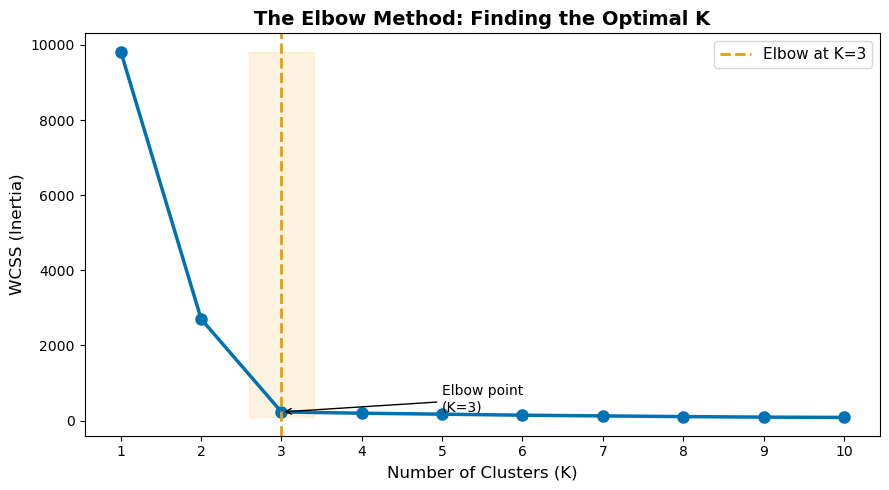

WCSS values: [9822.8, 2703.6, 229.7, 196.7, 171.5, 144.1, 124.9, 107.1, 92.6, 84.6]


In [3]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), wcss, 'o-', color=CB_COLORS[0], linewidth=2.5, markersize=8)
ax.axvline(x=3, color=CB_COLORS[1], linestyle='--', linewidth=2, label='Elbow at K=3')
ax.fill_betweenx([min(wcss), max(wcss)], 2.6, 3.4, color=CB_COLORS[1], alpha=0.12)

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_title('The Elbow Method: Finding the Optimal K', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(K_range))

# Annotate the elbow
ax.annotate('Elbow point\n(K=3)', xy=(3, wcss[2]), xytext=(5, wcss[2]+20),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')

# Alt text: Line chart of WCSS vs K from 1 to 10. WCSS drops sharply from K=1 to K=3,
# then flattens. A dashed vertical line and shaded region mark K=3 as the elbow point.
plt.tight_layout()
plt.savefig('fig2_elbow_method.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"WCSS values: {[round(w,1) for w in wcss]}")

## Step 5: The Silhouette Score — A Better Measure of Cluster Quality

The Silhouette Score measures how similar a point is to its own cluster compared to other clusters. It ranges from **-1 to +1**:
- **+1** → well clustered
- **0** → on the boundary between clusters  
- **-1** → likely assigned to the wrong cluster

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ = mean distance to same-cluster points, $b(i)$ = mean distance to nearest other cluster.

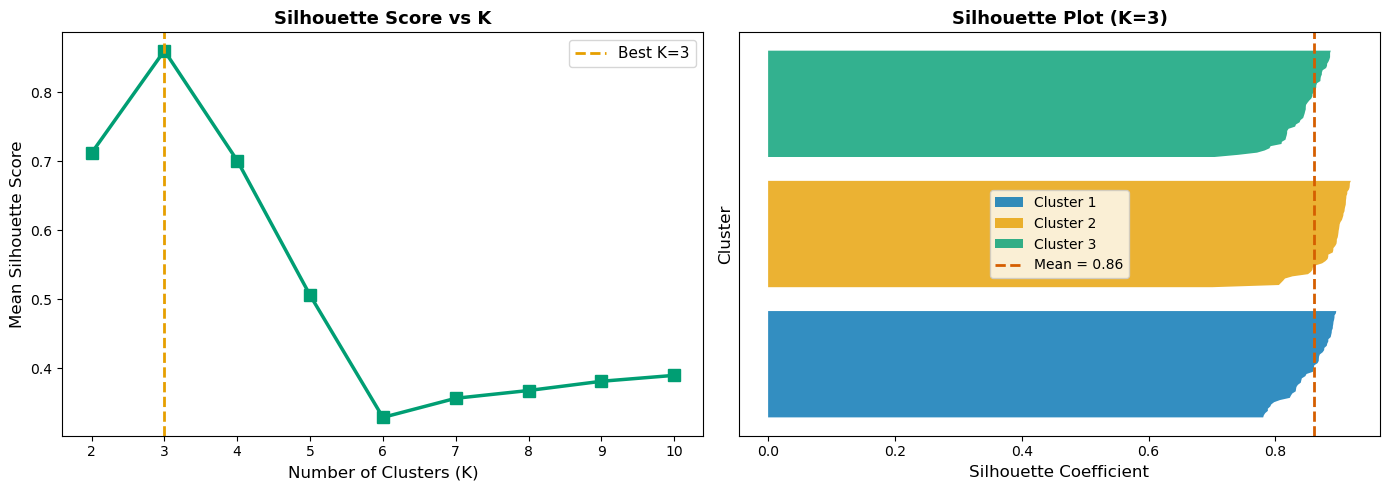

Best K by silhouette: 3 (score: 0.860)


In [4]:
sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

best_k = list(K_range_sil)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette score vs K
axes[0].plot(list(K_range_sil), sil_scores, 's-', color=CB_COLORS[2], linewidth=2.5, markersize=8)
axes[0].axvline(x=best_k, color=CB_COLORS[1], linestyle='--', linewidth=2, label=f'Best K={best_k}')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(K_range_sil))

# Silhouette plot for best K
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_best = km_best.fit_predict(X)
sil_vals = silhouette_samples(X, labels_best)

y_lower = 10
for k in range(best_k):
    vals = np.sort(sil_vals[labels_best == k])
    size = vals.shape[0]
    y_upper = y_lower + size
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                           facecolor=CB_COLORS[k], alpha=0.8, label=f'Cluster {k+1}')
    y_lower = y_upper + 10

axes[1].axvline(x=np.mean(sil_vals), color=CB_COLORS[3], linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(sil_vals):.2f}')
axes[1].set_xlabel('Silhouette Coefficient', fontsize=12)
axes[1].set_ylabel('Cluster', fontsize=12)
axes[1].set_title(f'Silhouette Plot (K={best_k})', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_yticks([])

# Alt text: Left: line chart of silhouette scores for K=2 to 10, peaking at K=3.
# Right: horizontal bar chart (silhouette plot) showing per-point silhouette coefficients
# for each of 3 clusters, all mostly positive and similar in size.
plt.tight_layout()
plt.savefig('fig3_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Best K by silhouette: {best_k} (score: {max(sil_scores):.3f})")

## Step 6: Real-World Application — Mall Customer Segmentation

We now apply K-Means to a real dataset: **Mall Customer Segmentation**. The goal is to segment customers by their **Annual Income** and **Spending Score** so a mall can target different customer groups with tailored marketing strategies.

In [5]:
# Download the dataset directly
import urllib.request
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/mall_customers.csv'
try:
    urllib.request.urlretrieve(url, 'mall_customers.csv')
    df = pd.read_csv('mall_customers.csv')
    print("Dataset downloaded successfully.")
except:
    # Fallback: generate realistic synthetic data if download fails
    print("Download failed — generating synthetic equivalent dataset.")
    np.random.seed(42)
    n = 200
    income    = np.concatenate([np.random.normal(20, 5, 40),  np.random.normal(25, 5, 40),
                                np.random.normal(55, 8, 40),  np.random.normal(70, 8, 40),
                                np.random.normal(85, 5, 40)])
    spending  = np.concatenate([np.random.normal(75, 8, 40),  np.random.normal(20, 7, 40),
                                np.random.normal(50, 6, 40),  np.random.normal(80, 8, 40),
                                np.random.normal(15, 7, 40)])
    df = pd.DataFrame({'Annual Income (k$)': np.clip(income, 10, 140),
                       'Spending Score (1-100)': np.clip(spending, 1, 100)})

# Standardise column names
df.columns = [c.strip() for c in df.columns]
# Try common column name patterns
income_col   = [c for c in df.columns if 'Income' in c or 'income' in c]
spending_col = [c for c in df.columns if 'Spending' in c or 'spending' in c]

if income_col and spending_col:
    X_mall = df[[income_col[0], spending_col[0]]].values
    xlabel, ylabel = income_col[0], spending_col[0]
else:
    X_mall = df.iloc[:, -2:].values
    xlabel, ylabel = df.columns[-2], df.columns[-1]

print(f"Dataset shape: {X_mall.shape}")
print(f"Features: {xlabel} | {ylabel}")
print(f"\nFirst 5 rows:\n{pd.DataFrame(X_mall, columns=[xlabel, ylabel]).head()}")

Download failed — generating synthetic equivalent dataset.
Dataset shape: (200, 2)
Features: Annual Income (k$) | Spending Score (1-100)

First 5 rows:
   Annual Income (k$)  Spending Score (1-100)
0           22.483571               77.862299
1           19.308678               79.486276
2           23.238443               83.664410
3           27.615149               83.430416
4           18.829233               63.978645


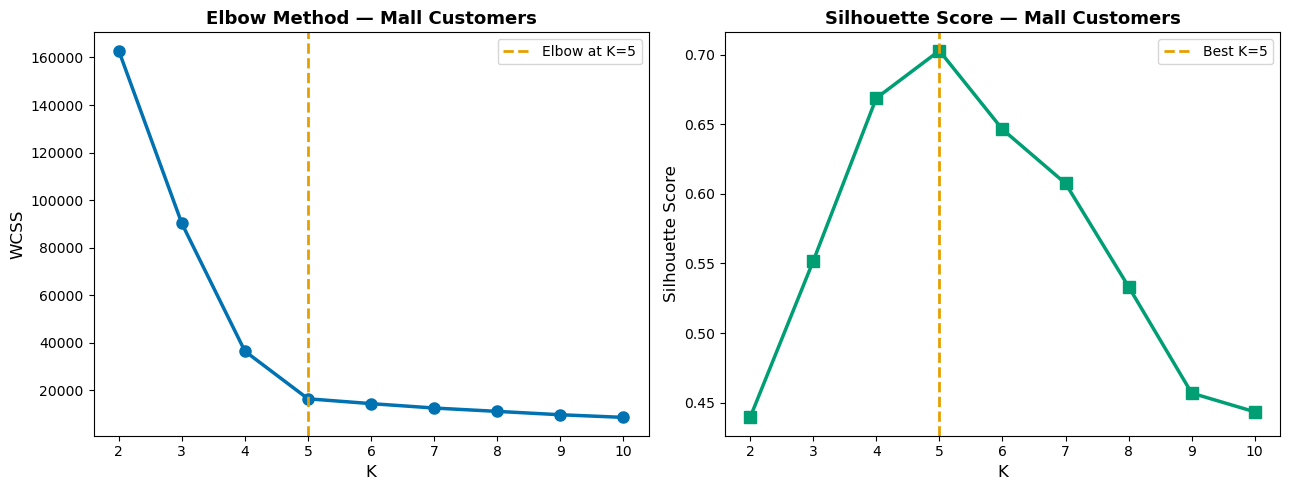

Optimal K: 5


In [6]:
# Find optimal K for mall dataset
wcss_mall = []
sil_mall  = []
K_range_mall = range(2, 11)

for k in K_range_mall:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(X_mall)
    wcss_mall.append(km.inertia_)
    sil_mall.append(silhouette_score(X_mall, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range_mall), wcss_mall, 'o-', color=CB_COLORS[0], linewidth=2.5, markersize=8)
axes[0].axvline(x=5, color=CB_COLORS[1], linestyle='--', linewidth=2, label='Elbow at K=5')
axes[0].set_xlabel('K', fontsize=12); axes[0].set_ylabel('WCSS', fontsize=12)
axes[0].set_title('Elbow Method — Mall Customers', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].set_xticks(list(K_range_mall))

axes[1].plot(list(K_range_mall), sil_mall, 's-', color=CB_COLORS[2], linewidth=2.5, markersize=8)
best_k_mall = list(K_range_mall)[np.argmax(sil_mall)]
axes[1].axvline(x=best_k_mall, color=CB_COLORS[1], linestyle='--', linewidth=2, label=f'Best K={best_k_mall}')
axes[1].set_xlabel('K', fontsize=12); axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Mall Customers', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].set_xticks(list(K_range_mall))

# Alt text: Two charts for the mall dataset. Left: elbow plot with WCSS decreasing, elbow at K=5.
# Right: silhouette scores peaking at K=5, confirming 5 as the optimal cluster count.
plt.tight_layout()
plt.savefig('fig4_mall_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Optimal K: {best_k_mall}")

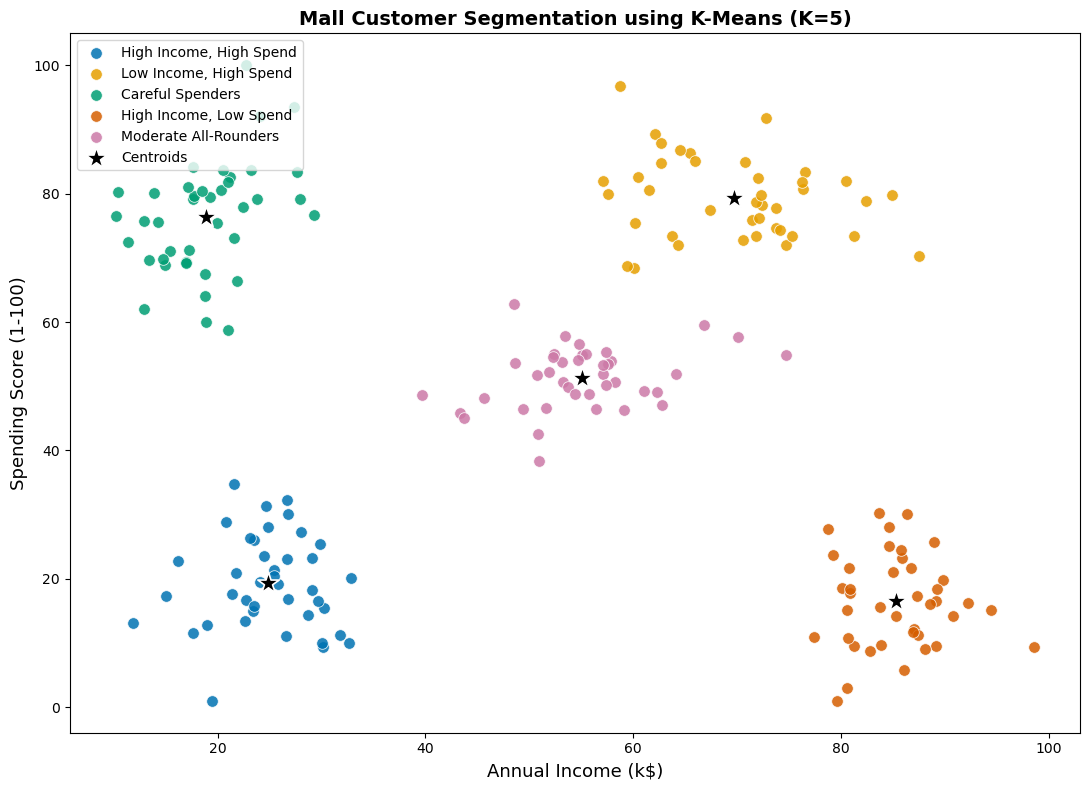


Cluster Profiles:
Cluster  Name                           Avg Income   Avg Spending   Size
------------------------------------------------------------------------
0        High Income, High Spend              24.9           19.3     40
1        Low Income, High Spend               69.7           79.4     40
2        Careful Spenders                     18.9           76.4     40
3        High Income, Low Spend               85.3           16.5     40
4        Moderate All-Rounders                55.1           51.3     40


In [7]:
# Apply K-Means with K=5 and visualise customer segments
K_FINAL = 5
km_mall = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
labels_mall = km_mall.fit_predict(X_mall)
centroids_mall = km_mall.cluster_centers_

SEGMENT_NAMES = [
    'Careful Spenders',
    'High Income, High Spend',
    'Moderate All-Rounders',
    'Low Income, High Spend',
    'High Income, Low Spend'
]

# Re-order segment names by centroid income
order = np.argsort(centroids_mall[:, 0])
name_map = {order[i]: SEGMENT_NAMES[i] for i in range(K_FINAL)}

fig, ax = plt.subplots(figsize=(11, 8))
for k in range(K_FINAL):
    mask = labels_mall == k
    ax.scatter(X_mall[mask, 0], X_mall[mask, 1],
               c=CB_COLORS[k], s=70, edgecolors='white', linewidth=0.6,
               alpha=0.85, label=name_map[k])

ax.scatter(centroids_mall[:, 0], centroids_mall[:, 1],
           c='black', s=260, marker='*', zorder=5,
           edgecolors='white', linewidth=1.2, label='Centroids')

ax.set_xlabel(xlabel, fontsize=13)
ax.set_ylabel(ylabel, fontsize=13)
ax.set_title('Mall Customer Segmentation using K-Means (K=5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

# Alt text: Scatter plot of Annual Income vs Spending Score for 200 customers,
# colour-coded into 5 segments. Black stars mark centroids. Five distinct clusters
# are visible: low-income high-spend, high-income high-spend, middle, etc.
plt.tight_layout()
plt.savefig('fig5_mall_segments.png', bbox_inches='tight', dpi=150)
plt.show()

# Segment statistics
print("\nCluster Profiles:")
print(f"{'Cluster':<8} {'Name':<28} {'Avg Income':>12} {'Avg Spending':>14} {'Size':>6}")
print("-" * 72)
for k in range(K_FINAL):
    mask = labels_mall == k
    print(f"{k:<8} {name_map[k]:<28} {X_mall[mask,0].mean():>12.1f} {X_mall[mask,1].mean():>14.1f} {mask.sum():>6}")

## Step 7: Visualise Voronoi Decision Boundaries

The decision boundaries of K-Means are **Voronoi regions** — each region contains all points closer to that centroid than any other. This helps visualise how the space is partitioned.

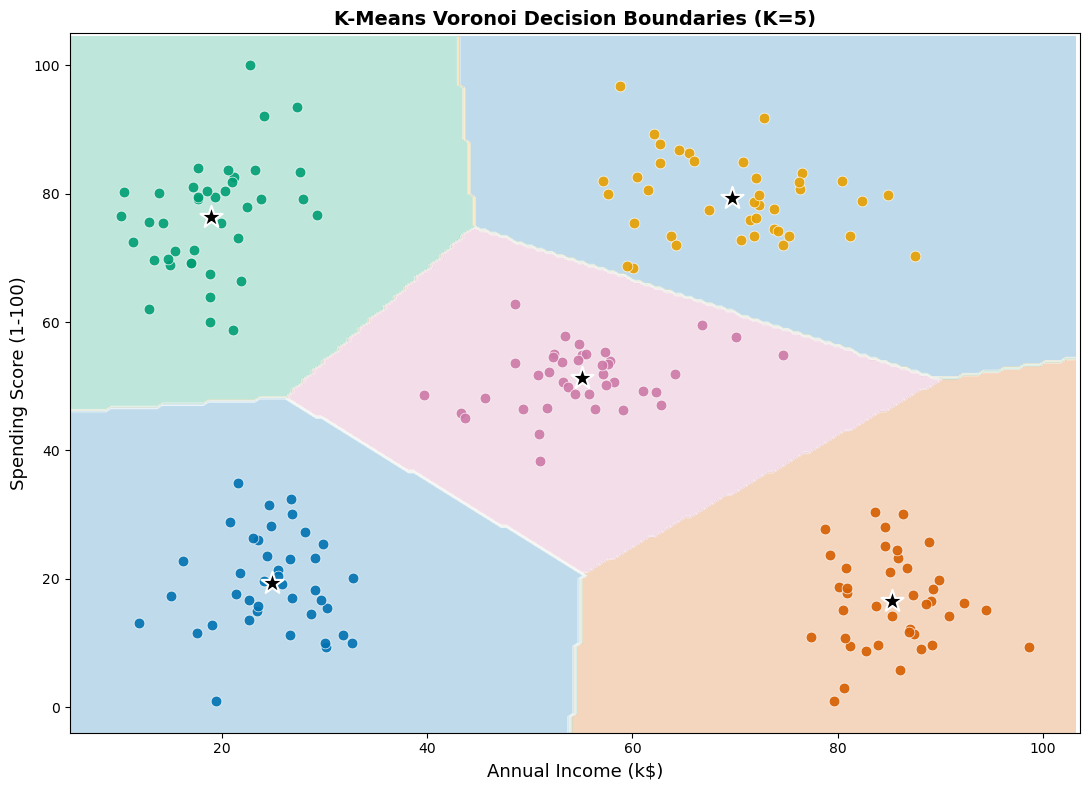

In [8]:
# Create a mesh grid and predict cluster for every point
h = 0.5  # step size
x_min, x_max = X_mall[:, 0].min() - 5, X_mall[:, 0].max() + 5
y_min, y_max = X_mall[:, 1].min() - 5, X_mall[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = km_mall.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 8))
# Plot background regions
from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap([c + '40' for c in CB_COLORS[:K_FINAL]])  # semi-transparent
ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(CB_COLORS[:K_FINAL]))
ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.6)

for k in range(K_FINAL):
    mask = labels_mall == k
    ax.scatter(X_mall[mask, 0], X_mall[mask, 1],
               c=CB_COLORS[k], s=60, edgecolors='white', linewidth=0.5, alpha=0.9)

ax.scatter(centroids_mall[:, 0], centroids_mall[:, 1],
           c='black', s=280, marker='*', zorder=5, edgecolors='white', linewidth=1.5)

ax.set_xlabel(xlabel, fontsize=13)
ax.set_ylabel(ylabel, fontsize=13)
ax.set_title('K-Means Voronoi Decision Boundaries (K=5)', fontsize=14, fontweight='bold')
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# Alt text: Scatter plot with 5 coloured background regions (Voronoi cells) separated by
# white boundary lines. Customer points sit within their respective regions. Black stars
# mark centroids at the centre of each region.
plt.tight_layout()
plt.savefig('fig6_voronoi.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 8: Limitations of K-Means

K-Means is powerful but has well-known limitations. The plot below demonstrates the three most important ones.

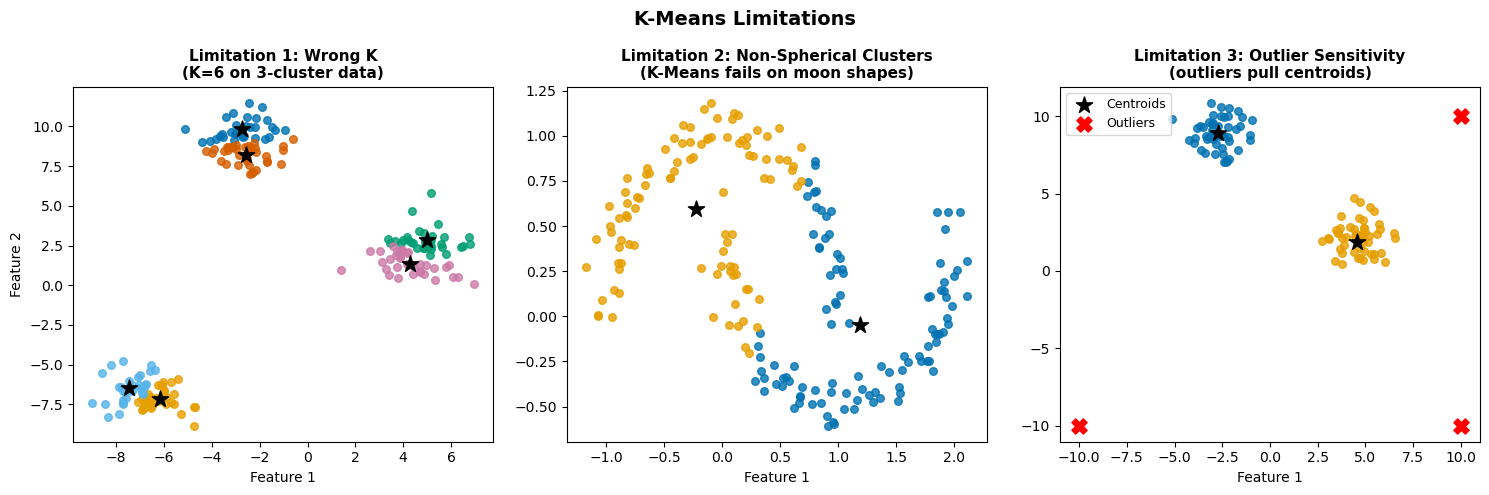

In [9]:
from sklearn.datasets import make_circles, make_moons

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Sensitivity to K (wrong K)
X_blobs, _ = make_blobs(n_samples=200, centers=3, random_state=42)
km_wrong = KMeans(n_clusters=6, n_init=10, random_state=42)
lbl_wrong = km_wrong.fit_predict(X_blobs)
for k in range(6):
    axes[0].scatter(X_blobs[lbl_wrong==k, 0], X_blobs[lbl_wrong==k, 1],
                    c=CB_COLORS[k % len(CB_COLORS)], s=30, alpha=0.8)
axes[0].scatter(km_wrong.cluster_centers_[:, 0], km_wrong.cluster_centers_[:, 1],
                c='black', s=150, marker='*', zorder=5)
axes[0].set_title('Limitation 1: Wrong K\n(K=6 on 3-cluster data)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# 2. Non-spherical clusters (moons)
X_moons, y_moons = make_moons(n_samples=200, noise=0.08, random_state=42)
km_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
lbl_moons = km_moons.fit_predict(X_moons)
for k in range(2):
    axes[1].scatter(X_moons[lbl_moons==k, 0], X_moons[lbl_moons==k, 1],
                    c=CB_COLORS[k], s=30, alpha=0.8)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                c='black', s=150, marker='*', zorder=5)
axes[1].set_title('Limitation 2: Non-Spherical Clusters\n(K-Means fails on moon shapes)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature 1')

# 3. Sensitivity to outliers
X_out = np.vstack([make_blobs(n_samples=100, centers=2, random_state=42)[0],
                   np.array([[10, 10], [-10, -10], [10, -10]])])  # 3 outliers
km_out = KMeans(n_clusters=2, n_init=10, random_state=42)
lbl_out = km_out.fit_predict(X_out)
for k in range(2):
    axes[2].scatter(X_out[lbl_out==k, 0], X_out[lbl_out==k, 1],
                    c=CB_COLORS[k], s=30, alpha=0.8)
axes[2].scatter(km_out.cluster_centers_[:, 0], km_out.cluster_centers_[:, 1],
                c='black', s=150, marker='*', zorder=5, label='Centroids')
axes[2].scatter([10, -10, 10], [10, -10, -10], c='red', s=120, marker='X', zorder=6, label='Outliers')
axes[2].legend(fontsize=9)
axes[2].set_title('Limitation 3: Outlier Sensitivity\n(outliers pull centroids)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Feature 1')

fig.suptitle('K-Means Limitations', fontsize=14, fontweight='bold')
# Alt text: Three scatter plots showing K-Means failures.
# Left: 3-cluster data over-segmented into 6 clusters.
# Middle: Two crescent moon shapes incorrectly split vertically.
# Right: Outliers (red X) pulling centroids away from true cluster centres.
plt.tight_layout()
plt.savefig('fig7_limitations.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary

In this tutorial, we:

1. **Explained** the K-Means algorithm (Lloyd's algorithm) — initialise, assign, update, repeat
2. **Visualised** convergence step-by-step on synthetic data
3. **Determined optimal K** using the Elbow Method (WCSS) and Silhouette Score
4. **Applied K-Means** to real mall customer data — identifying 5 meaningful customer segments
5. **Visualised** Voronoi decision boundaries showing how space is partitioned
6. **Demonstrated** key limitations: wrong K, non-spherical clusters, outlier sensitivity

### Key Takeaway

K-Means is a powerful, interpretable, and computationally efficient unsupervised algorithm. It works best when clusters are roughly spherical and similarly sized, and when K is chosen carefully using the Elbow Method or Silhouette Score. When these assumptions don't hold, consider alternatives like DBSCAN or Gaussian Mixture Models.

---

**GitHub:** https://github.com/thanushayan/kmeans_clustering_tutorial.git

